In [1]:
# Cell 1: Imports and paths

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
CLEAN_DIR = OUTPUT_DIR / "cleaned"

CLEAN_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
# Cell 2: Common cleaning functions

def clean_num(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("NA", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

def normalize_state(x):
    x = str(x).strip().replace("&", "and")
    x = " ".join(x.split()).title()
    fixes = {
        "Andaman And Nicobar Island": "Andaman And Nicobar Islands",
        "Ut Of Dnh And Dd": "Dadra And Nagar Haveli And Daman And Diu",
        "Nct Of Delhi": "Delhi",
    }
    return fixes.get(x, x)

def is_ev_fuel(x):
    x = str(x).strip().lower()
    return x in ["ev", "electric", "electric(bov)", "electric (bov)", "electric bov"]

def cagr(start, end, years):
    if pd.isna(start) or pd.isna(end) or start <= 0 or years <= 0:
        return np.nan
    return ((end / start) ** (1 / years) - 1) * 100

def safe_pct_change(current, previous):
    if pd.isna(current) or pd.isna(previous) or previous == 0:
        return np.nan
    return ((current - previous) / previous) * 100

In [4]:
import sys
!{sys.executable} -m pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Cell 3: Load wheel/fuel yearly dataset for CAGR and penetration

wheel_raw = pd.read_excel(
    DATA_DIR / "Dataset_Wheel_Fuel_Yearly_2011-2025.xlsx",
    sheet_name="FY2011-2025",
    engine="openpyxl"
)

year_cols = [c for c in wheel_raw.columns if str(c).startswith("FY")]

national = wheel_raw.iloc[0:4][["Unnamed: 0", "Unnamed: 1"] + year_cols].copy()
national.columns = ["Category", "Fuel_Type"] + year_cols
national["Category"] = "All Vehicles"

category = wheel_raw.iloc[7:].copy()
category = category[["Unnamed: 0", "Unnamed: 1"] + year_cols]
category.columns = ["Category", "Fuel_Type"] + year_cols
category = category.dropna(subset=["Category", "Fuel_Type"])

yearly = pd.concat([national, category], ignore_index=True)

yearly_long = yearly.melt(
    id_vars=["Category", "Fuel_Type"],
    value_vars=year_cols,
    var_name="Financial_Year",
    value_name="Registrations"
)

yearly_long["Year"] = yearly_long["Financial_Year"].str.extract(r"(\d{4})").astype(int)
yearly_long["Registrations"] = clean_num(yearly_long["Registrations"]).fillna(0)
yearly_long["Is_EV"] = yearly_long["Fuel_Type"].apply(is_ev_fuel)

display(yearly_long.head())

,Category,Fuel_Type,Financial_Year,Registrations,Year,Is_EV
0,All Vehicles,Total,FY2011,14483963.0,2011,False
1,All Vehicles,EV,FY2011,4904.0,2011,True
2,All Vehicles,Petrol,FY2011,11718948.0,2011,False
3,All Vehicles,Diesel,FY2011,2277069.0,2011,False
4,2W,Total,FY2011,10489721.0,2011,False


Overall EV CAGR (2015-2025): 96.04%


,Category,Registrations_Start,Registrations_End,CAGR_Percent
2,3W Passenger,10.0,135266.0,158.892140
1,3W Goods,4.0,28044.0,142.425331
3,Bus,3.0,3393.0,101.997624
0,2W,1569.0,1209658.0,94.403449
6,LGV (up to 7/5 tonnes),14.0,5617.0,82.111612
4,Cars,634.0,115315.0,68.259523
5,HGV (>12 tonnes),5.0,127.0,38.192149
8,Others,163.0,376.0,8.717642
7,MGV (7.5-12 tonnes),0.0,0.0,NaN


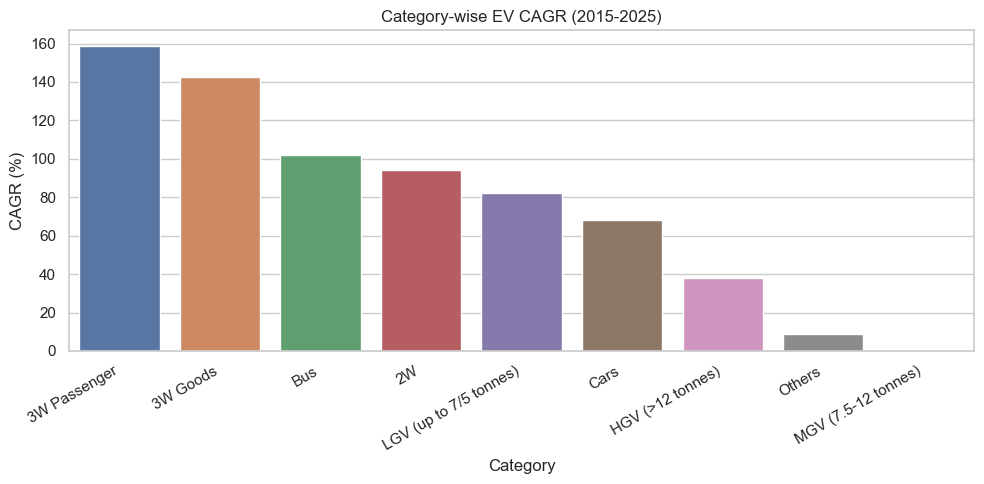

In [6]:
# Cell 4: CAGR analysis, 2015-2025

ev_yearly = yearly_long[yearly_long["Is_EV"]].copy()

national_ev = (
    ev_yearly[ev_yearly["Category"] == "All Vehicles"]
    .groupby("Year", as_index=False)["Registrations"]
    .sum()
)

start_year = 2015
end_year = 2025

start_value = national_ev.loc[national_ev["Year"] == start_year, "Registrations"].sum()
end_value = national_ev.loc[national_ev["Year"] == end_year, "Registrations"].sum()

overall_cagr = cagr(start_value, end_value, end_year - start_year)

print(f"Overall EV CAGR ({start_year}-{end_year}): {overall_cagr:.2f}%")

category_ev = (
    ev_yearly[ev_yearly["Category"] != "All Vehicles"]
    .groupby(["Category", "Year"], as_index=False)["Registrations"]
    .sum()
)

cat_start = category_ev[category_ev["Year"] == start_year][["Category", "Registrations"]]
cat_end = category_ev[category_ev["Year"] == end_year][["Category", "Registrations"]]

category_cagr = cat_start.merge(cat_end, on="Category", suffixes=("_Start", "_End"))
category_cagr["CAGR_Percent"] = category_cagr.apply(
    lambda r: cagr(r["Registrations_Start"], r["Registrations_End"], end_year - start_year),
    axis=1
)

category_cagr = category_cagr.sort_values("CAGR_Percent", ascending=False)
display(category_cagr)

plt.figure(figsize=(10, 5))
sns.barplot(data=category_cagr, x="Category", y="CAGR_Percent", hue="Category", legend=False)
plt.title("Category-wise EV CAGR (2015-2025)")
plt.xticks(rotation=30, ha="right")
plt.ylabel("CAGR (%)")
plt.tight_layout()
plt.show()

,Category,Year,Total_Registrations,EV_Registrations,EV_Penetration_Percent
49,All Vehicles,2015,19403029.0,2343.0,0.012075
50,All Vehicles,2016,20122809.0,16169.0,0.080352
51,All Vehicles,2017,21651768.0,55844.0,0.257919
52,All Vehicles,2018,23959683.0,96491.0,0.402722
53,All Vehicles,2019,25317093.0,146941.0,0.580402
54,All Vehicles,2020,24592926.0,173613.0,0.705947
55,All Vehicles,2021,17521374.0,142419.0,0.812830
56,All Vehicles,2022,18445111.0,459065.0,2.488817
57,All Vehicles,2023,22331887.0,1183331.0,5.298840
58,All Vehicles,2024,24640843.0,1678063.0,6.810088


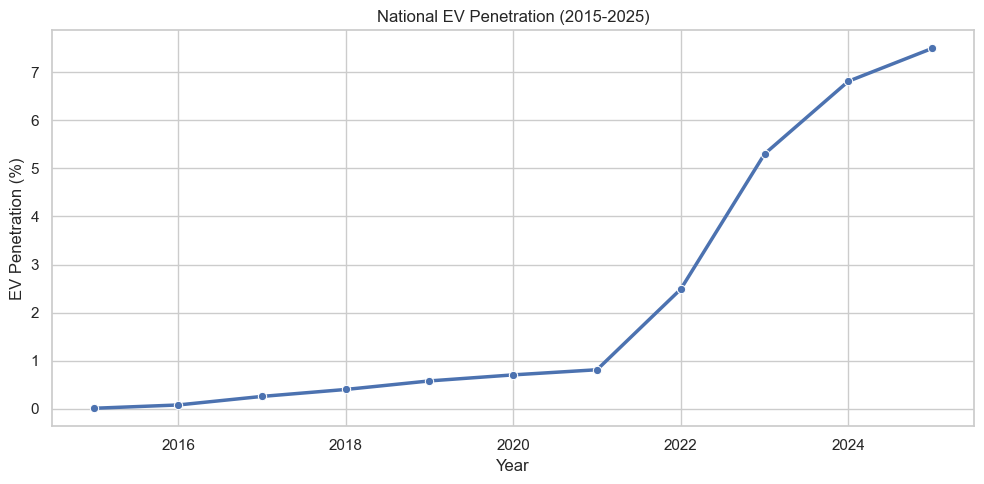

,Category,Year,Total_Registrations,EV_Registrations,EV_Penetration_Percent
44,3W Passenger,2025,594281.00,135266.0,22.761286
29,3W Goods,2025,130220.00,28044.0,21.535862
14,2W,2025,19551827.00,1209658.0,6.186931
74,Bus,2025,114542.00,3393.0,2.962232
89,Cars,2025,4270569.00,115315.0,2.700226
119,LGV (up to 7/5 tonnes),2025,527772.42,5617.0,1.064284
104,HGV (>12 tonnes),2025,235991.00,127.0,0.053816
149,Others,2025,1118234.00,376.0,0.033624
134,MGV (7.5-12 tonnes),2025,39560.00,0.0,0.000000


In [7]:
# Cell 5: Penetration analysis, 2015-2025

total_regs = (
    yearly_long[yearly_long["Fuel_Type"].str.lower() == "total"]
    .groupby(["Category", "Year"], as_index=False)["Registrations"]
    .sum()
    .rename(columns={"Registrations": "Total_Registrations"})
)

ev_regs = (
    yearly_long[yearly_long["Is_EV"]]
    .groupby(["Category", "Year"], as_index=False)["Registrations"]
    .sum()
    .rename(columns={"Registrations": "EV_Registrations"})
)

penetration = total_regs.merge(ev_regs, on=["Category", "Year"], how="left").fillna(0)
penetration["EV_Penetration_Percent"] = (
    penetration["EV_Registrations"] / penetration["Total_Registrations"].replace(0, np.nan)
) * 100

national_pen = penetration[
    (penetration["Category"] == "All Vehicles") &
    (penetration["Year"].between(2015, 2025))
]

display(national_pen)

plt.figure(figsize=(10, 5))
sns.lineplot(data=national_pen, x="Year", y="EV_Penetration_Percent", marker="o", linewidth=2.5)
plt.title("National EV Penetration (2015-2025)")
plt.ylabel("EV Penetration (%)")
plt.tight_layout()
plt.show()

category_pen_2025 = penetration[
    (penetration["Category"] != "All Vehicles") &
    (penetration["Year"] == 2025)
].sort_values("EV_Penetration_Percent", ascending=False)

display(category_pen_2025)

In [9]:
# Cell 6: State monthly EV dataset

state_raw = pd.read_csv(DATA_DIR / "Dataset_state_Fuel_Month_2019-2024.csv")

state_raw["date"] = pd.to_datetime(state_raw["date"], errors="coerce")
state_raw["state_name"] = state_raw["state_name"].apply(normalize_state)
state_raw["registrations"] = clean_num(state_raw["registrations"]).fillna(0)
state_raw["Year"] = state_raw["date"].dt.year
state_raw["Month"] = state_raw["date"].dt.month
state_raw["Is_EV"] = state_raw["fuel_type"].apply(is_ev_fuel)

state_ev_monthly = (
    state_raw[state_raw["Is_EV"]]
    .groupby(["state_name", "date", "Year", "Month"], as_index=False)["registrations"]
    .sum()
    .rename(columns={"state_name": "State", "date": "Date", "registrations": "EV_Registrations"})
)

state_annual = (
    state_ev_monthly
    .groupby(["State", "Year"], as_index=False)["EV_Registrations"]
    .sum()
)

display(state_annual.head())
display(state_annual.groupby("Year")["EV_Registrations"].sum().reset_index())

,State,Year,EV_Registrations
0,Andaman And Nicobar Islands,2019,2.0
1,Andaman And Nicobar Islands,2020,36.0
2,Andaman And Nicobar Islands,2021,92.0
3,Andaman And Nicobar Islands,2022,23.0
4,Andaman And Nicobar Islands,2023,26.0


,Year,EV_Registrations
0,2019,168619.0
1,2020,2595149.0
2,2021,2316128.0
3,2022,6232335.0
4,2023,4703953.0
5,2024,1508548.0


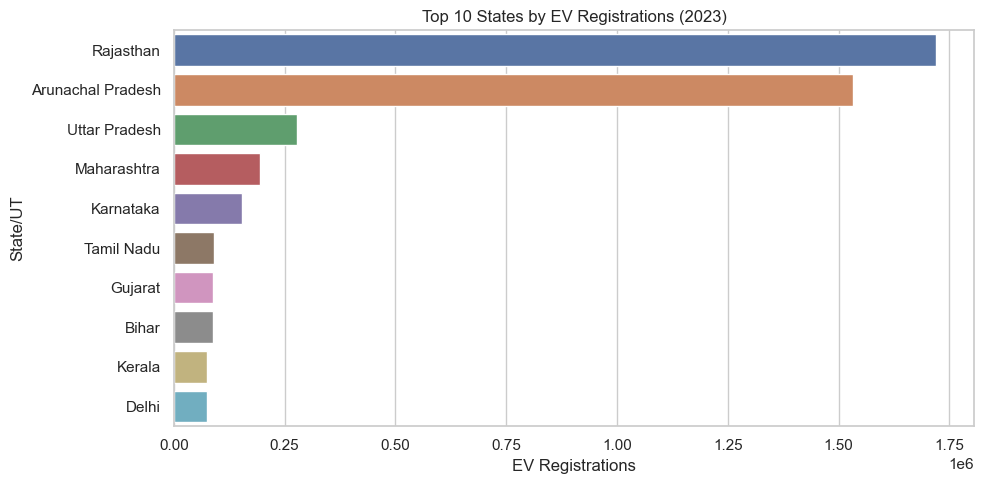

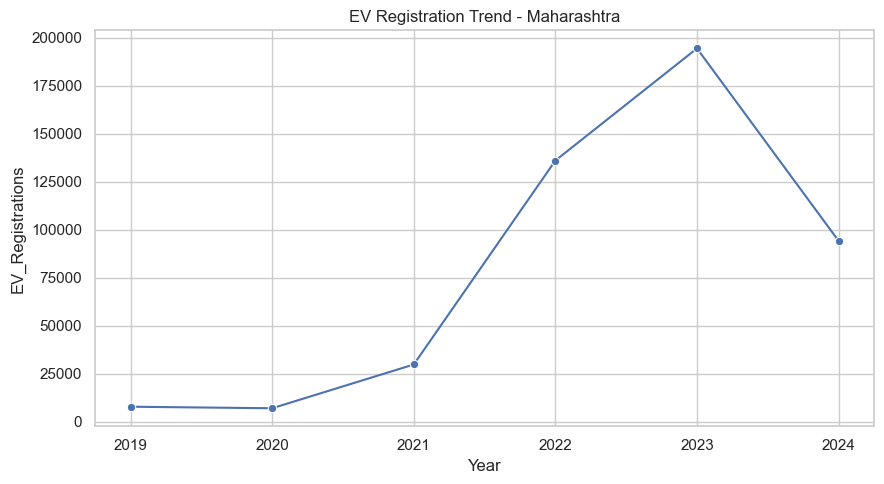

In [10]:
# Cell 7: State analysis charts

latest_complete_year = 2023  # 2024 is partial in the new monthly dataset

top_states = (
    state_annual[state_annual["Year"] == latest_complete_year]
    .sort_values("EV_Registrations", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_states, x="EV_Registrations", y="State", hue="State", legend=False)
plt.title(f"Top 10 States by EV Registrations ({latest_complete_year})")
plt.xlabel("EV Registrations")
plt.ylabel("State/UT")
plt.tight_layout()
plt.show()

state_choice = "Maharashtra"
state_trend = state_annual[state_annual["State"] == state_choice]

plt.figure(figsize=(9, 5))
sns.lineplot(data=state_trend, x="Year", y="EV_Registrations", marker="o")
plt.title(f"EV Registration Trend - {state_choice}")
plt.tight_layout()
plt.show()

In [11]:
# Cell 8: Forecasting helper

FORECAST_END_YEAR = 2030

def forecast_monthly(group, value_col="EV_Registrations", degree=2):
    actual = group[["Date", value_col]].copy().sort_values("Date")
    actual = actual.groupby("Date", as_index=False)[value_col].sum()
    actual = actual[actual[value_col] >= 0]

    full_dates = pd.date_range(actual["Date"].min(), actual["Date"].max(), freq="MS")
    actual = pd.DataFrame({"Date": full_dates}).merge(actual, on="Date", how="left").fillna(0)

    last_date = actual["Date"].max()
    future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(1), f"{FORECAST_END_YEAR}-12-01", freq="MS")
    all_dates = pd.concat([actual["Date"], pd.Series(future_dates)], ignore_index=True)

    nonzero_months = (actual[value_col] > 0).sum()

    if len(actual) >= 6 and nonzero_months >= 4:
        X = np.arange(len(actual)).reshape(-1, 1)
        X_all = np.arange(len(all_dates)).reshape(-1, 1)

        model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=1.0))
        model.fit(X, actual[value_col])

        fitted = model.predict(X)
        predicted = np.clip(model.predict(X_all), 0, None)
        r2 = r2_score(actual[value_col], fitted)
        method = "Polynomial Ridge Regression"
    else:
        base = actual[value_col].tail(6).mean()
        predicted = np.array(list(actual[value_col]) + [base] * len(future_dates))
        r2 = np.nan
        method = "Fallback Average"

    forecast = pd.DataFrame({
        "Date": all_dates,
        "Actual": list(actual[value_col]) + [np.nan] * len(future_dates),
        "Predicted": predicted
    })

    forecast["Year"] = forecast["Date"].dt.year
    forecast["Month"] = forecast["Date"].dt.month

    return forecast, r2, method

In [12]:
# Cell 9: State forecast till 2030, no state skipped

state_forecasts = []
state_metrics = []

for state, group in state_ev_monthly.groupby("State"):
    pred, r2, method = forecast_monthly(group)

    nonzero_months = (group["EV_Registrations"] > 0).sum()

    if nonzero_months >= 36 and pd.notna(r2) and r2 >= 0.50:
        confidence = "High"
    elif nonzero_months >= 18:
        confidence = "Medium"
    else:
        confidence = "Low"

    pred["State"] = state
    state_forecasts.append(pred)

    state_metrics.append({
        "State": state,
        "Model_Fit_Score": r2,
        "Nonzero_EV_Months": nonzero_months,
        "Forecast_Method": method,
        "Forecast_Confidence": confidence
    })

state_forecast = pd.concat(state_forecasts, ignore_index=True)
state_metrics = pd.DataFrame(state_metrics)

state_2030 = (
    state_forecast[state_forecast["Year"] == 2030]
    .groupby("State", as_index=False)["Predicted"]
    .sum()
    .rename(columns={"Predicted": "Predicted_EV_Registrations_2030"})
    .merge(state_metrics, on="State", how="left")
    .sort_values("Predicted_EV_Registrations_2030", ascending=False)
)

display(state_2030.head(15))
display(state_metrics["Forecast_Confidence"].value_counts())

,State,Predicted_EV_Registrations_2030,Model_Fit_Score,Nonzero_EV_Months,Forecast_Method,Forecast_Confidence
26,Rajasthan,1.017835e+07,0.907057,65,Polynomial Ridge Regression,High
31,Uttar Pradesh,2.003977e+06,0.928144,65,Polynomial Ridge Regression,High
18,Maharashtra,1.255809e+06,0.839312,65,Polynomial Ridge Regression,High
14,Karnataka,8.991845e+05,0.820345,65,Polynomial Ridge Regression,High
9,Gujarat,3.877783e+05,0.743136,64,Polynomial Ridge Regression,High
23,Odisha,3.567858e+05,0.873919,65,Polynomial Ridge Regression,High
3,Assam,3.114843e+05,0.863430,65,Polynomial Ridge Regression,High
6,Chhattisgarh,2.925481e+05,0.861597,65,Polynomial Ridge Regression,High
10,Haryana,1.797398e+05,0.857020,65,Polynomial Ridge Regression,High
4,Bihar,1.754406e+05,0.065373,65,Polynomial Ridge Regression,Medium


Forecast_Confidence
High      17
Medium    14
Low        3
Name: count, dtype: int64

In [13]:
# Cell 10: Save cleaned EDA outputs

yearly_long.to_csv(CLEAN_DIR / "wheel_fuel_yearly_cleaned.csv", index=False)
penetration.to_csv(CLEAN_DIR / "penetration_cleaned.csv", index=False)
category_cagr.to_csv(CLEAN_DIR / "category_cagr_2015_2025.csv", index=False)
state_ev_monthly.to_csv(CLEAN_DIR / "state_monthly_ev_cleaned.csv", index=False)
state_forecast.to_csv(OUTPUT_DIR / "state_forecast_monthly_2030.csv", index=False)
state_2030.to_csv(OUTPUT_DIR / "state_forecast_2030_summary.csv", index=False)

print("EDA outputs saved.")

EDA outputs saved.
